# LeR Short Example

This notebook is created by [Phurailatpam Hemantakumar](https://hemantaph.com)

[![Documentation](https://img.shields.io/badge/ler-documentation-blue)](https://ler.hemantaph.com) 

`ler` is a comprehensive framework for simulating gravitational wave (GW) events and calculating their detection rates, including gravitational lensing effects. 
- The **`LeR`** class is the primary interface for these simulations.
- The **`GWRATES`** class focuses on standard (unlensed) Compact Binary Coalescence (CBC) events. Refer to the **GWRATES complete example** for more details.

This notebook demonstrates how to simulate both lensed and unlensed CBC populations and compare their detection rates using the `LeR` class.

## Table of Contents
1. [LeR initialization with default arguments](#1-ler-initialization-with-default-arguments)
2. [Basic GW Event Simulation and Rate Calculation](#2-basic-gw-event-simulation-and-rate-calculation)
   - [2.1 Simulate Unlensed GW Population](#2-1-simulate-unlensed-gw-population)
   - [2.2 Calculate Unlensed Detection Rates](#2-2-calculate-unlensed-detection-rates)
   - [2.3 Inspect Generated Unlensed Parameters](#2-3-inspect-generated-unlensed-parameters)
3. [Lensed GW Population Simulation and Rates](#3-lensed-gw-population-simulation-and-rates)
   - [3.1 Simulate Lensed GW Population](#3-1-simulate-lensed-gw-population)
   - [3.2 Calculate Lensed Detection Rates](#3-2-calculate-lensed-detection-rates)
   - [3.3 Inspect Generated Lensed Parameters](#3-3-inspect-generated-lensed-parameters)
4. [Rate Comparison and Visualization](#4-rate-comparison-and-visualization)
   - [4.1 Compare Lensed vs Unlensed Rates](#4-1-compare-lensed-vs-unlensed-rates)
   - [4.2 Access Saved Data Files](#4-2-access-saved-data-files)
   - [4.3 Load and Examine Saved Parameters](#4-3-load-and-examine-saved-parameters)
   - [4.4 Visualize Parameter Distributions](#4-4-visualize-parameter-distributions)
5. [Available Internal Functions and Their Usage](#5-available-internal-functions-and-their-usage)
   - [5.1 Explore Functions and Parameters](#5-1-explore-functions-and-parameters)
   - [5.2 Short Example on Using Internal Functions](#5-2-short-example-on-using-internal-functions)
6. [Summary](#6-summary)

---

## 1. LeR initialization with default arguments

The `LeR` class is the main interface for simulating unlensed and lensed GW events and calculating detection rates. By default, it uses:

- **Event type:** BBH (Binary Black Hole).
- **Lens galaxy model:** EPL+Shear (Elliptical Power Law galaxy with external shears).
- **Detectors:** H1, L1, V1 (LIGO Hanford, LIGO Livingston, Virgo) with O4 design sensitivity.

etc.

All outputs will be saved in the `./ler_data` directory by default.

In [1]:
# Import LeR
from ler import LeR

# Initialize LeR with default settings
# use this gwsnr's input args if you want SNR values in the output, besides the boolean detection probability values. This will increase the output dictionary size and the runtime of the code. For details, refer to https://gwsnr.hemantaph.com/examples/pdet_generation.html. 
# pdet_kwargs=dict(snr_th=10.0, snr_th_net=10.0, pdet_type="boolean", distribution_type="noncentral_chi2", include_optimal_snr=True, include_observed_snr=True)
ler = LeR(npool=6)
# if Cross section interpolation data points are newly created, time: 5m (npool=6)

Extracting interpolator data from package to the current working directory.

Initializing LeR class...


Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ./interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_ewoud
velocity_dispersion_ewoud interpolator will be loaded from ./interpolator_json/velocity_dispersion/velocity_dispersion_ewoud_0.json
using ler available axis_ratio function : rayleigh
rayleigh 

To print all initialization input arguments, use:

```python
    ler._print_all_init_args()
```

---

>> **Note :** Alternative (important) possible gwsnr input arguments for the `LeR` class initialization. Refer to `gwsnr` [Documentation](https://gwsnr.hemantaph.com) for more details on the input arguments.

```python
    ler = LeR(
        # if you want SNR values in the output, besides the boolean detection probability values
        pdet_kwargs=dict(
            snr_th=10.0, 
            snr_th_net=10.0, 
            pdet_type="boolean", 
            distribution_type="noncentral_chi2", # or 'fixed_snr' if you want to use optimal_snr values, instead of observed_snr values, in pdet calculation.
            include_optimal_snr=True, 
            include_observed_snr=True)
        # if you want to use spin precessing waveforms
        waveform_approximant = 'IMRPhenomXPHM', 
        snr_recalculation = True,
        snr_recalculation_range = [6, 14],
        snr_recalculation_waveform_approximant = 'IMRPhenomXPHM',
        # ler settings to access spin precessing GW parameters
        spin_zero = False,
        spin_precession=True, 
    )
```

---

## 2. Basic GW Event Simulation and Rate Calculation

This section demonstrates how to simulate unlensed binary black hole mergers and calculate their detection rates.

### 2.1 Simulate Unlensed GW Population

Generate a population of unlensed Compact Binary Coalescence (CBC) events. This step:
- Samples intrinsic (masses and spins) and extrinsic (redshift, sky location, inclination angle, etc.) GW parameters from initialized priors.
- Calculates the probability of detection (Pdet) for each event based on the detector network sensitivity.
- Stores the output in `./ler_data/unlensed_param.json`.

**Note:** For realistic results, use `size >= 1,000,000` with `batch_size = 100,000`

In [2]:
# Simulate 100,000 unlensed GW events in batches of 50,000
# use 'print(ler.unlensed_cbc_statistics.__doc__)' to see all the input args
unlensed_param = ler.unlensed_cbc_statistics(size=100000, batch_size=50000, resume=False)

print(f"\nTotal unlensed events simulated: {len(unlensed_param['zs'])}")
print(f"Sampled source redshift values (first 5): {unlensed_param['zs'][:5]}")

unlensed params will be stored in ./ler_data/unlensed_param.json
removing ./ler_data/unlensed_param.json if it exists
Batch no. 1
sampling gw source params...
calculating pdet...
Batch no. 2
sampling gw source params...
calculating pdet...
saving all unlensed parameters in ./ler_data/unlensed_param.json 

Total unlensed events simulated: 100000
Sampled source redshift values (first 5): [1.05789155 1.27781901 3.14671465 3.02773773 4.50519348]


### 2.2 Calculate Unlensed Detection Rates

Select detectable events and calculate the detection rate. This function:
- Filters events using a Pdet threshold. By default, Pdet is based on observed detector network SNR > 10 (`gwsnr`'s default), where the SNR follows a non-central chi-squared distribution centered at the optimal SNR (Essick et al. 2023).
- Returns the rate in detectable events per year.
- Saves detectable events to `./ler_data/unlensed_param_detectable.json`.

In [3]:
# Calculate the detection rate and extract detectable unlensed events
# use 'print(ler.unlensed_rate.__doc__)' to see all the input args
rate_unlensed, unlensed_param_detectable = ler.unlensed_rate()

print(f"\n=== Unlensed Detection Rate Summary ===")
print(f"Detectable event rate: {rate_unlensed:.2e} events per year")
print(f"Total event rate: {ler.normalization_pdf_z:.2e} events per year")
print(f"Percentage fraction of the detectable events: {rate_unlensed/ler.normalization_pdf_z*100:.2e}%")

Getting unlensed_param from json file ./ler_data/unlensed_param.json...
total unlensed rate (yr^-1): 380.07276807448415
number of simulated unlensed detectable events: 415
number of simulated all unlensed events: 100000
storing detectable params in ./ler_data/unlensed_param_detectable.json

=== Unlensed Detection Rate Summary ===
Detectable event rate: 3.80e+02 events per year
Total event rate: 9.16e+04 events per year
Percentage fraction of the detectable events: 4.15e-01%


>> **Note :** rate calculation considers 100% duty cycle for all detectors in the network for a span of 1 year.

### 2.3 Inspect Generated Unlensed Parameters

View the available parameters in the generated event population.

In [4]:
# List all parameters available in the detectable event population
print("Detectable unlensed event parameters:")
print(list(unlensed_param_detectable.keys()))

print("\nExample values for mass_1_source (first 5 events):")
print(unlensed_param_detectable['mass_1_source'][:5])

Detectable unlensed event parameters:
['zs', 'mass_1_source', 'mass_ratio', 'mass_2_source', 'geocent_time', 'ra', 'dec', 'phase', 'psi', 'theta_jn', 'a_1', 'a_2', 'luminosity_distance', 'mass_1', 'mass_2', 'pdet_L1', 'pdet_H1', 'pdet_V1', 'pdet_net']

Example values for mass_1_source (first 5 events):
[ 37.75155669  19.1792205   35.94794391   9.63533786
 100.11176524]


---

## 3. Lensed GW Population Simulation and Rates

This part demonstrates the simulation of lensed GW events and rate calculation. Lensing includes additional parameters such as lens galaxy properties (lens redshift, velocity dispersion, etc.) and image characteristics (magnification, time delays, etc.).

### 3.1 Simulate Lensed GW Population

Generate a population of lensed CBC events including lens galaxy properties and image parameters:
- Source parameters (redshift, masses, spins)
- Lens parameters (redshift, Einstein radius, ellipticity, shear components)
- Image parameters (magnifications, time delays)

This step stores output in `./ler_data/lensed_param.json`

**Note:** The simulation includes:
- Lens galaxy population sampling
- Selection based on lensing cross-section
- Lens equation solving for multiple image generation
- Pdet calculation for each image

In [5]:
# Simulate 100,000 unlensed GW events in batches of 50,000
# use 'ler.lensed_cbc_statistics.__doc__' to see all the input args
lensed_param = ler.lensed_cbc_statistics(size=100000, batch_size=50000, resume=False)

print(f"\nTotal lensed events simulated: {len(lensed_param['zs'])}")
print(f"Sampled source redshift values (first 5): {lensed_param['zs'][:5]}")
# Initialization of the underlying numba njit function for the first time can take some time ~25 seconds, but subsequent calls will be faster.

lensed params will be stored in ./ler_data/lensed_param.json
removing ./ler_data/lensed_param.json if it exists
Batch no. 1
sampling lensed params...
sampling lens parameters with epl_shear_sl_parameters_rvs...
computing image properties using ler's epl+shear (analytical, njit) solver...
Invalid sample found. Resampling 133 lensed events...
sampling lens parameters with epl_shear_sl_parameters_rvs...
computing image properties using ler's epl+shear (analytical, njit) solver...
calculating pdet...
Batch no. 2
sampling lensed params...
sampling lens parameters with epl_shear_sl_parameters_rvs...
computing image properties using ler's epl+shear (analytical, njit) solver...
Invalid sample found. Resampling 127 lensed events...
sampling lens parameters with epl_shear_sl_parameters_rvs...
computing image properties using ler's epl+shear (analytical, njit) solver...
Invalid sample found. Resampling 1 lensed events...
sampling lens parameters with epl_shear_sl_parameters_rvs...
computing image

In [6]:
# include other useful parameters in the output dictionary.
# It is omitted by default to save runtime and memory.
# For theta_E, n_images, mass_1, mass_2, luminosity_distance:
lensed_param = ler.recover_redundant_parameters(lensed_param)
# For effective_luminosity_distance, effective_geocent_time, effective_phase, effective_ra, effective_dec:
lensed_param = ler.produce_effective_params(lensed_param)

# or you can simply set 'include_redundant_parameters=True, include_effective_parameters=True' in the input args of LeR initialization to include these parameters in the output dictionary by default.

### 3.2 Calculate Lensed Detection Rates

- Calculate the lensed detection rate, with each event requiring at least two detectable images for a valid detection.
- The detection rate is stored in `./ler_data/lensed_param_detectable.json`.

In [7]:
# Calculate the detection rate for lensed events
# use 'print(ler.lensed_rate.__doc__)' to see all the input args
rate_lensed, lensed_param_detectable = ler.lensed_rate()

print(f"\n=== Lensed Detection Rate Summary ===")
print(f"Detectable event rate: {rate_lensed:.2e} events per year")
print(f"Total event rate: {ler.normalization_pdf_z_lensed:.2e} events per year")
print(f"Percentage fraction of the detectable events: {rate_lensed/ler.normalization_pdf_z_lensed*100:.2e}%")

Getting lensed_param from json file ./ler_data/lensed_param.json...
total lensed rate (yr^-1): 0.13450206598263986
number of simulated lensed detectable events: 121
number of simulated all lensed events: 100000
storing detectable params in ./ler_data/lensed_param_detectable.json

=== Lensed Detection Rate Summary ===
Detectable event rate: 1.35e-01 events per year
Total event rate: 1.11e+02 events per year
Percentage fraction of the detectable events: 1.21e-01%


In [8]:
# Recover redundant parameters (like theta_E, n_images, mass_1, mass_2, luminosity_distance) for the detectable lensed events
lensed_param_detectable = ler.recover_redundant_parameters(lensed_param_detectable)
lensed_param_detectable = ler.produce_effective_params(lensed_param_detectable)

### 3.3 Inspect Generated Lensed Parameters

In [9]:
# List all parameters available in the detectable lensed event population
print("Detectable lensed event parameters:")
print(list(lensed_param_detectable.keys()))

print("\nLens-specific parameters include:")
lens_params = ['zl', 'sigma', 'q', 'phi', 'gamma', 'gamma1', 'gamma2']
for param in lens_params:
    if param in lensed_param_detectable:
        print(f"  {param}: {lensed_param_detectable[param][:3]}")

Detectable lensed event parameters:
['zl', 'zs', 'sigma', 'q', 'phi', 'gamma', 'gamma1', 'gamma2', 'mass_ratio', 'geocent_time', 'ra', 'dec', 'phase', 'psi', 'theta_jn', 'a_1', 'a_2', 'mass_1', 'mass_2', 'x0_image_positions', 'x1_image_positions', 'magnifications', 'time_delays', 'image_type', 'x_source', 'y_source', 'pdet_L1', 'pdet_H1', 'pdet_V1', 'pdet_net', 'theta_E', 'n_images', 'mass_1_source', 'mass_2_source', 'luminosity_distance', 'effective_luminosity_distance', 'effective_geocent_time', 'effective_phase', 'effective_ra', 'effective_dec']

Lens-specific parameters include:
  zl: [0.78185048 0.92853533 2.3191688 ]
  sigma: [150.5397603  183.03427494 190.47182539]
  q: [0.8417591  0.28002366 0.62086284]
  phi: [2.64329537 4.9661625  3.16484811]
  gamma: [2.00077048 2.02610238 2.15955123]
  gamma1: [ 0.05430789 -0.03174526 -0.08064444]
  gamma2: [-0.040133   0.0334945  0.0978488]


---

## 4. Rate Comparison and Visualization

Compare the lensed and unlensed detection rates, access saved data files, and visualize parameter distributions.

### 4.1 Compare Lensed vs Unlensed Rates

In [10]:
# Compare lensed and unlensed rates
# the following will throw an error if you try to calculate the rate ratio before calculating the lensed and unlensed rates.
rate_ratio = ler.rate_ratio()

print(f"\n=== Rate Comparison ===")
print(f"Unlensed detection rate: {rate_unlensed:.4e} events/yr")
print(f"Lensed detection rate: {rate_lensed:.4e} events/yr")
print(f"Rate ratio (lensed/unlensed): {rate_ratio:.4f}")

unlensed_rate: 380.07276807448415
lensed_rate: 0.13450206598263986
ratio: 2825.776431742989

=== Rate Comparison ===
Unlensed detection rate: 3.8007e+02 events/yr
Lensed detection rate: 1.3450e-01 events/yr
Rate ratio (lensed/unlensed): 2825.7764


>> **Bonus :** The following command simultaneously selects detectable events, calculates rates, and compares unlensed and lensed events.

```python
    unlensed_rate, lensed_rate, rate_ratio, unlensed_param_detectable, lensed_param_detectable = ler.rate_comparison_with_rate_calculation()
```

### 4.2 Access Saved Data Files

All simulation results are saved in JSON files for future reference and analysis. View the saved file locations and load parameters from disk.

In [11]:
# View saved file locations and names
print(f"Output directory: {ler.ler_directory}")
print(f"\nSaved JSON files:")
for key, filename in ler.json_file_names.items():
    print(f"  {key}: {filename}")

Output directory: ./ler_data

Saved JSON files:
  ler_params: ler_params.json
  unlensed_param: unlensed_param.json
  unlensed_param_detectable: unlensed_param_detectable.json
  lensed_param: lensed_param.json
  lensed_param_detectable: lensed_param_detectable.json


### 4.3 Load and Examine Saved Parameters

Reload parameters from JSON files for further analysis. This example also hightlights some of the useful functions from `ler.utils` module.

In [12]:
# Load parameters from saved JSON files
from ler.utils import get_param_from_json, load_json

# Load detectable parameters from files
unlensed_param_from_file = get_param_from_json(
    ler.ler_directory + '/' + ler.json_file_names['unlensed_param_detectable']
)
lensed_param_from_file = get_param_from_json(
    ler.ler_directory + '/' + ler.json_file_names['lensed_param_detectable']
)

print(f"Unlensed parameters loaded: {list(unlensed_param_from_file.keys())}")
print(f"Lensed parameters loaded: {list(lensed_param_from_file.keys())}")

# Load initialization parameters and results
ler_params = load_json(ler.ler_directory + '/ler_params.json')
print(f"\n=== Rates from saved file ===")
print(f"Detectable unlensed rate: {ler_params['detectable_unlensed_rate_per_year']:.4e} events/yr")
print(f"Detectable lensed rate: {ler_params['detectable_lensed_rate_per_year']:.4e} events/yr")
print(f"Rate ratio: {ler_params['rate_ratio']:.4f}")

Unlensed parameters loaded: ['zs', 'mass_1_source', 'mass_ratio', 'mass_2_source', 'geocent_time', 'ra', 'dec', 'phase', 'psi', 'theta_jn', 'a_1', 'a_2', 'luminosity_distance', 'mass_1', 'mass_2', 'pdet_L1', 'pdet_H1', 'pdet_V1', 'pdet_net']
Lensed parameters loaded: ['zl', 'zs', 'sigma', 'q', 'phi', 'gamma', 'gamma1', 'gamma2', 'mass_ratio', 'geocent_time', 'ra', 'dec', 'phase', 'psi', 'theta_jn', 'a_1', 'a_2', 'mass_1', 'mass_2', 'x0_image_positions', 'x1_image_positions', 'magnifications', 'time_delays', 'image_type', 'x_source', 'y_source', 'pdet_L1', 'pdet_H1', 'pdet_V1', 'pdet_net']

=== Rates from saved file ===
Detectable unlensed rate: 3.8007e+02 events/yr
Detectable lensed rate: 1.3450e-01 events/yr
Rate ratio: 2825.7764


### 4.4 Visualize Parameter Distributions

Create KDE (Kernel Density Estimation) plots to compare the distributions of source redshift for lensed and unlensed populations.

getting gw_params from json file ler_data/unlensed_param_detectable.json...
getting gw_params from json file ler_data/unlensed_param.json...
getting gw_params from json file ler_data/lensed_param_detectable.json...
getting gw_params from json file ler_data/lensed_param.json...


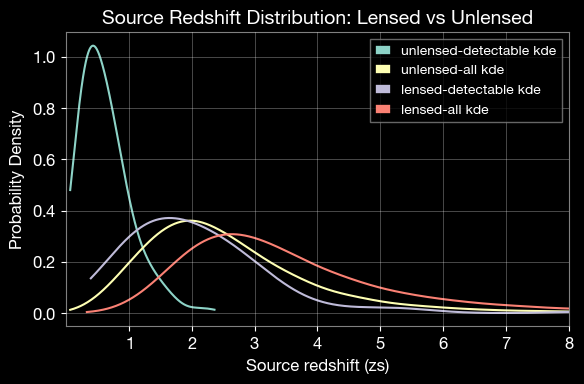

In [13]:
# Visualize parameter distributions
import matplotlib.pyplot as plt
from ler.utils import plots as lerplt

# Plot source redshift distributions
plt.figure(figsize=(6, 4))

# Unlensed populations
lerplt.param_plot(
    param_name='zs',
    param_dict='ler_data/unlensed_param_detectable.json', # can also provide the dict directly
    plot_label='unlensed-detectable',
    histogram=False,
    kde=True,
    kde_bandwidth=0.5,
)
lerplt.param_plot(
    param_name='zs',
    param_dict='ler_data/unlensed_param.json',
    plot_label='unlensed-all',
    histogram=False,
    kde=True,
)

# Lensed populations
lerplt.param_plot(
    param_name='zs',
    param_dict='ler_data/lensed_param_detectable.json',
    plot_label='lensed-detectable',
    histogram=False,
    kde=True,
    kde_bandwidth=0.5,
)
lerplt.param_plot(
    param_name='zs',
    param_dict='ler_data/lensed_param.json',
    plot_label='lensed-all',
    histogram=False,
    kde=True,
)

plt.xlim(0.001, 8)
plt.grid(alpha=0.4)
plt.xlabel('Source redshift (zs)', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title('Source Redshift Distribution: Lensed vs Unlensed', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

---

## 5. Available Internal Functions and Their Usage

### 5.1 Explore Functions and Parameters

Inspect the internal functions and parameters used for `LeR` initialization.

In [14]:
# List all available GW functions are in ler.available_gw_functions
print("# ----------------------------------------------------")
print("Source related functions and their input arguments:")
print("# ----------------------------------------------------\n")
for func_name, func_params in ler.available_gw_functions.items():
    print(f"{func_name}:")
    
    if isinstance(func_params, dict):
        for param_name, param_value in func_params.items():
            print(f"  {param_name}: {param_value}")
    else:
        print(f"  {func_params}")
    print()

for func_name, func_params in ler.available_gw_prior.items():
    print(f"{func_name}:")
    
    if isinstance(func_params, dict):
        for param_name, param_value in func_params.items():
            print(f"  {param_name}: {param_value}")
    else:
        print(f"  {func_params}")
    print()

# List all available GW prior are in ler.available_gw_prior 
print("# ----------------------------------------------------")
print("# GW prior sampler functions and their input arguments:")
print("# ----------------------------------------------------\n")
for key, value in ler.available_gw_prior.items():
    print(f"{key} = dict(")
    if isinstance(value, dict):
        for k, v in value.items():
            print(f"    {k} = {v},")
    else:
        print(f"    {value},")
    print(")")

# list all available lens prior are in ler.available_lens_priors
print("\n# ----------------------------------------------------")
print("# Lens prior sampler functions and their input arguments:")
print("# ----------------------------------------------------\n")
for key, value in ler.available_lens_priors.items():
    print(f"{key} = dict(")
    if isinstance(value, dict):
        for k, v in value.items():
            print(f"    {k} = {v},")
    else:
        print(f"    {value},")
    print(")")

# list all available lens functions are in ler.available_lens_functions
print("\n# ----------------------------------------------------")
print("# Other lens related functions and their input arguments:")
print("# ----------------------------------------------------\n")
for key, value in ler.available_lens_functions.items():
    print(f"{key} = dict(")
    if isinstance(value, dict):
        for k, v in value.items():
            print(f"    {k} = {v},")
    else:
        print(f"    {value},")
    print(")")

# ----------------------------------------------------
Source related functions and their input arguments:
# ----------------------------------------------------

merger_rate_density:
  merger_rate_density_madau_dickinson_belczynski_ng: {'param_name': 'merger_rate_density', 'function_type': 'merger_rate_density_madau_dickinson_belczynski_ng', 'R0': 1.9e-08, 'alpha_F': 2.57, 'beta_F': 5.83, 'c_F': 3.36}
  merger_rate_density_bbh_oguri2018: {'param_name': 'merger_rate_density', 'function_type': 'merger_rate_density_bbh_oguri2018', 'R0': 1.9e-08, 'b2': 1.6, 'b3': 2.1, 'b4': 30}
  merger_rate_density_madau_dickinson2014: {'param_name': 'merger_rate_density', 'function_type': 'merger_rate_density_madau_dickinson2014', 'R0': 8.9e-08, 'a': 0.015, 'b': 2.7, 'c': 2.9, 'd': 5.6}
  sfr_with_time_delay: {'param_name': 'merger_rate_density', 'function_type': 'sfr_with_time_delay', 'R0': 1.9e-08, 'a': 0.01, 'b': 2.6, 'c': 3.2, 'd': 6.2, 'td_min': 0.01, 'td_max': 10.0}
  merger_rate_density_bbh_popII

### 5.2 Short Example on Using Internal Functions

Following is a code snippet to initialize `LeR` with internal functions. Refer to the dedicated `LeR with custom functions` example for more details.

```python
ler = LeR(
    # CBCSourceParameterDistribution class arguments
    gw_functions = dict(
        merger_rate_density = 'merger_rate_density_madau_dickinson_belczynski_ng', # function to calculate the merger rate density at a given redshift
    ), 
    gw_functions_params = dict(
        merger_rate_density = {'param_name': 'merger_rate_density', 'function_type': 'merger_rate_density_madau_dickinson_belczynski_ng', 'R0': 1.9e-08, 'alpha_F': 2.57, 'beta_F': 5.83, 'c_F': 3.36},
    ), 
    gw_priors = dict(
        mass_1_source = 'broken_powerlaw_plus_2peaks',
    ),
    gw_priors_params = dict(
        mass_1_source = {'param_name': 'mass_1_source', 'sampler_type': 'broken_powerlaw_plus_2peaks', 'lam_0': 0.361, 'lam_1': 0.586, 'mpp_1': 9.764, 'sigpp_1': 0.649, 'mpp_2': 32.763, 'sigpp_2': 3.918, 'mlow_1': 5.059, 'delta_m_1': 4.321, 'break_mass': 35.622, 'alpha_1': 1.728, 'alpha_2': 4.512, 'mmax': 300.0, 'normalization_size': 500},
    ),

    # LensGalaxyParameterDistribution class arguments
    lens_functions = dict(
        optical_depth = 'optical_depth_numerical',
    ),
    lens_functions_params = dict(
        optical_depth = None,
    ),
    lens_param_samplers = dict(
        velocity_dispersion = 'velocity_dispersion_ewoud',
    ),
    lens_param_samplers_params = dict(
        velocity_dispersion = {'sigma_min': 100.0, 'sigma_max': 400.0, 'alpha': 0.94, 'beta': 1.85, 'phistar': 0.02099, 'sigmastar': 113.78},
    ),
)
```

---

## 6. Summary

This notebook demonstrates gravitational wave detection rate simulations using the **LeR** framework for both unlensed and strongly lensed compact binary coalescence (CBC) events.

**Workflow:** Initialize LeR with default BBH sources, EPL+Shear lens model, and O4-sensitivity detectors (H1, L1, V1) → simulate 100,000 unlensed CBC events and compute detection rates → sample lens galaxy properties, solve lens equations, and compute lensed rates (requiring ≥2 detectable images) → compare rates and visualize redshift distributions.

**Sampled Parameters:**
- *GW source:* redshift, masses, spins, sky location, orientation, luminosity distance, detection probability
- *Lens:* redshift, velocity dispersion, Einstein radius, axis ratio, density slope, shear
- *Images:* magnifications, time delays, image types, effective luminosity distances

**Output Files** (saved to `./ler_data/`): `unlensed_param.json`, `unlensed_param_detectable.json`, `lensed_param.json`, `lensed_param_detectable.json`, `ler_params.json`

**Customization:** Access built-in samplers via `ler.available_gw_prior`, `ler.available_lens_samplers`, and `ler.available_lens_functions`. See the **LeR with custom functions** example for advanced configurations.